In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Image Degradation

In [3]:
def plot_degrade_results(
    data,
    title,
    x_labels,
    x_label_name,
    std_data=None,
    error_style="shade",  # "shade", "bars", or None
    save_path=None
):
    # ---- FONT SIZES ----
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 28,
        "axes.labelsize": 22,
        "xtick.labelsize": 22,
        "ytick.labelsize": 15,
        "legend.fontsize": 22,
        "lines.markersize": 8,
        "lines.linewidth": 3
    })

    x = np.arange(len(x_labels))
    #plt.figure(figsize=(9,6.5))
    plt.figure(figsize=(8.7,6.5))

    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_idx = 0

    has_zero_shot = any("zero-shot" in vals for vals in data.values())

    for model, vals in data.items():
        model_color = None
        model_std = std_data.get(model, {}) if std_data else {}

        def plot_line(y, yerr, label, linestyle, marker):
            nonlocal model_color

            if error_style == "bars" and yerr is not None:
                line = plt.errorbar(
                    x, y, yerr=yerr,
                    linestyle=linestyle,
                    marker=marker,
                    linewidth=2,
                    capsize=4,
                    color=model_color,
                    label=label
                )
                if model_color is None:
                    model_color = line[0].get_color()

            else:
                line, = plt.plot(
                    x, y,
                    linestyle=linestyle,
                    marker=marker,
                    linewidth=2,
                    color=model_color,
                    label=label
                )
                if model_color is None:
                    model_color = line.get_color()

                if error_style == "shade" and yerr is not None:
                    plt.fill_between(
                        x,
                        np.array(y) - np.array(yerr),
                        np.array(y) + np.array(yerr),
                        alpha=0.2,
                        color=model_color
                    )

        if "ovdsat" in vals:
            plot_line(vals["ovdsat"], model_std.get("ovdsat"), f"{model}", "-", "o")

        if "coop" in vals:
            plot_line(vals["coop"], model_std.get("coop"), f"{model} + CoOp", "--", "D")

        if model_color is None:
            model_color = color_cycle[color_idx % len(color_cycle)]
            color_idx += 1

        if has_zero_shot and "zero-shot" in vals:
            z = vals["zero-shot"]
            zerr = model_std.get("zero-shot")

            plt.plot(
                -0.5, z,
                marker="*",
                markersize=20,
                linestyle="None",
                color=model_color,
                label=f"{model} zero-shot"
            )

            if error_style == "shade" and zerr is not None:
                plt.fill_between(
                    [-0.5],
                    [z - zerr],
                    [z + zerr],
                    alpha=0.2,
                    color=model_color
                )

    if has_zero_shot:
        plt.xticks(np.concatenate(([-0.5], x)), ["Zero-\nshot"] + x_labels)
        plt.xlim(-0.8, len(x_labels) - 0.5)
    else:
        plt.xticks(x, x_labels)

    #plt.xlabel(x_label_name)
    #plt.ylabel("mAP50")
    plt.title(title, pad=15)

    ymin, ymax = plt.ylim()
    plt.ylim(ymin, ymax * 1.05)

    # ---- ONLY CHANGE: legend fix ----
    from matplotlib.lines import Line2D
    handles, labels = plt.gca().get_legend_handles_labels()

    # remove per-model zero-shot entries
    handles = [h for h, l in zip(handles, labels) if "zero-shot" not in l]
    labels = [l for l in labels if "zero-shot" not in l]

    # add single black star entry
    handles.append(Line2D([0], [0], marker='*', color='black',
                          linestyle='None', markersize=12))
    labels.append("Zero-shot")

    plt.xticks(np.concatenate(([-0.5], x)), ["Zero-\nshot"] + x_labels)
    tick_labels = plt.gca().get_xticklabels()
    tick_labels[(["Zero-\nshot"] + x_labels).index("Normal")].set_ha('left')

    #plt.legend(handles, labels, loc="upper right", frameon=True)

    plt.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),  # move below plot
        ncol=len(labels),             # one horizontal row
        frameon=True,
        handlelength=2
    )

    #plt.xticks(rotation=45)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

/state/partition1/slurm_tmp/4422959.0.0/ipykernel_1943973/699019859.py:149: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


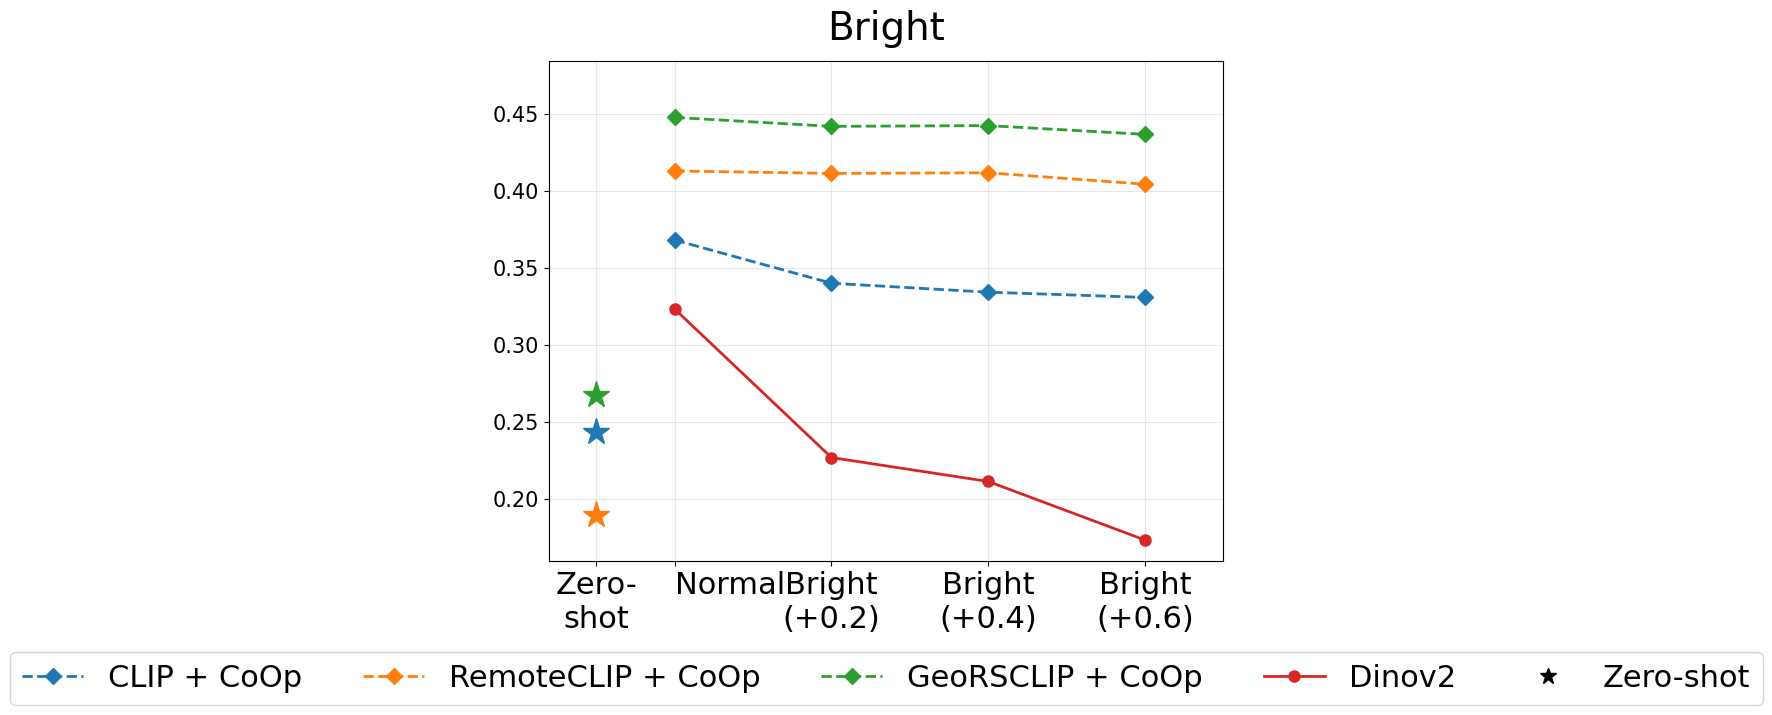

/state/partition1/slurm_tmp/4422959.0.0/ipykernel_1943973/699019859.py:149: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


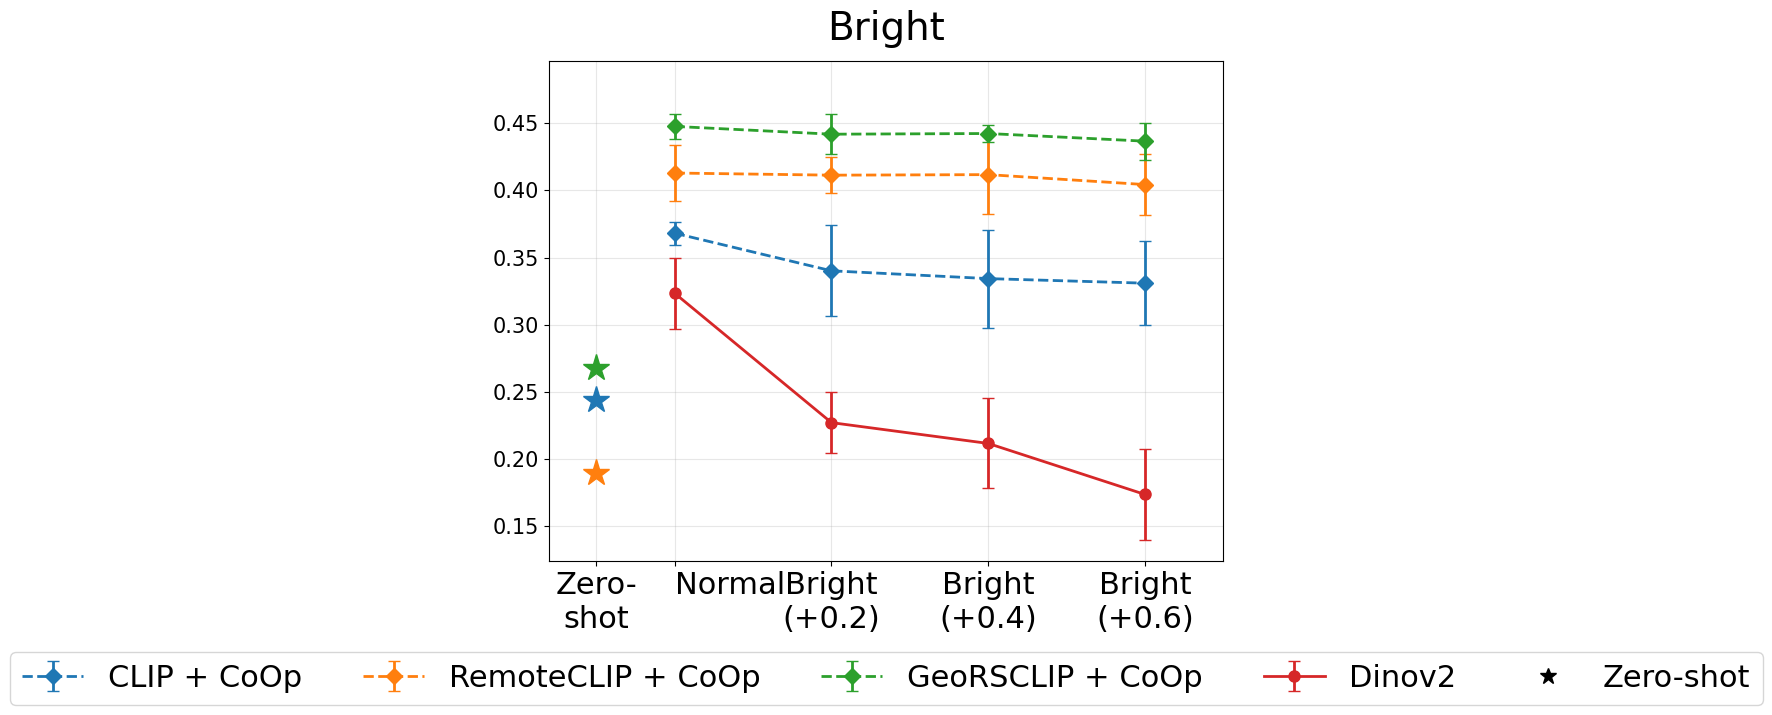

In [4]:
# SIMD, 4 end
bright_labels = ["Normal", "Bright\n(+0.2)", "Bright\n(+0.4)", "Bright\n(+0.6)"]

data_10shot = {
    "CLIP": {
        "zero-shot": 0.2438,
        "coop": [0.3681, 0.3401, 0.3343, 0.3309],
    },
    "RemoteCLIP": {
        "zero-shot": 0.1898,
        "coop": [0.4129, 0.4113, 0.4117, 0.4043],
    },
    "GeoRSCLIP": {
        "zero-shot": 0.2679,
        "coop": [0.4476, 0.4418, 0.4423, 0.4366],
    },
    "Dinov2": {
        "ovdsat": [0.3234, 0.2271, 0.2116, 0.1736],
    },
}

std_10shot = {
    "CLIP": {
        "coop": [0.0086, 0.0340, 0.0365, 0.0315],
    },
    "RemoteCLIP": {
        "coop": [0.0206, 0.0135, 0.0292, 0.0228],
    },
    "GeoRSCLIP": {
        "coop": [0.0094, 0.0149, 0.0065, 0.0137],
    },
    "Dinov2": {
        "ovdsat": [0.0266, 0.0229, 0.0335, 0.0338],
    },
}

plot_degrade_results(
    data_10shot,
    "Bright",
    bright_labels,
    "Brightness Increase"
)

plot_degrade_results(
    data_10shot,
    "Bright",
    bright_labels,
    "Brightness Increase",
    std_data=std_10shot,
    error_style='bars'
)

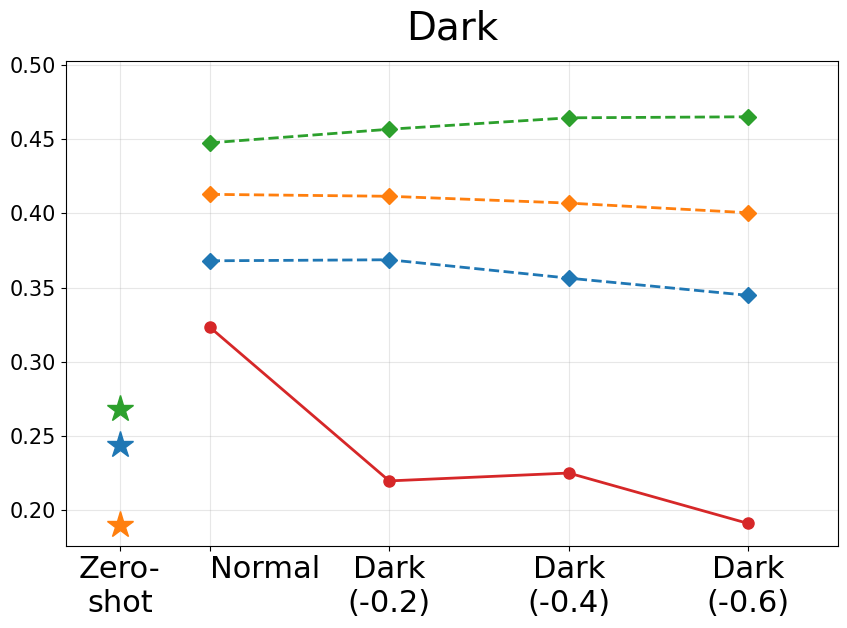

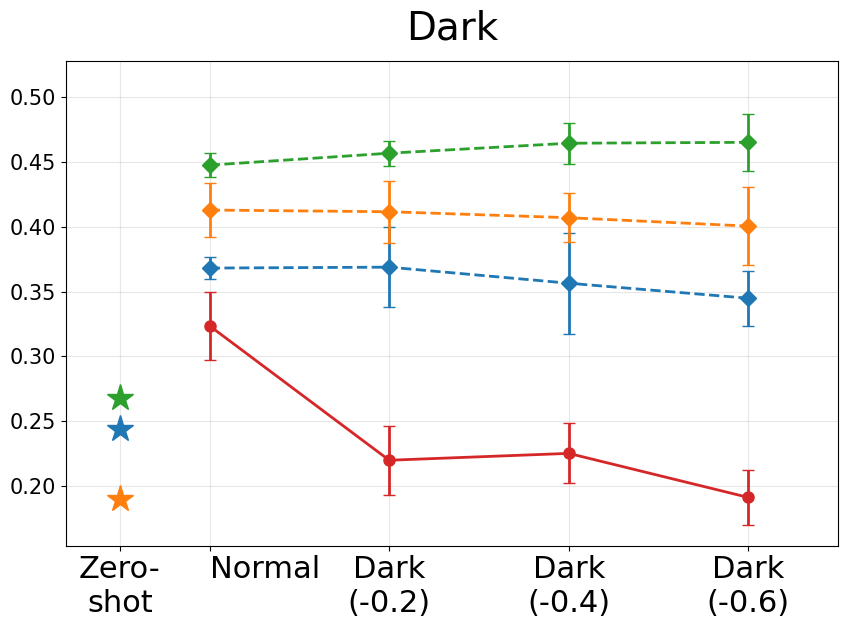

In [12]:
# SIMD, 4 end

dark_labels = ["Normal", "Dark\n(-0.2)", "Dark\n(-0.4)", "Dark\n(-0.6)"]

data_10shot = {
    "CLIP": {
        "zero-shot": 0.2438,
        "coop": [0.3681, 0.3688, 0.3564, 0.3448],
    },
    "RemoteCLIP": {
        "zero-shot": 0.1898,
        "coop": [0.4129, 0.4116, 0.4070, 0.4005],
    },
    "GeorsCLIP": {
        "zero-shot": 0.2679,
        "coop": [0.4476, 0.4568, 0.4645, 0.4652],
    },
    "Dinov2": {
        "ovdsat": [0.3234, 0.2197, 0.2250, 0.1910],
    },
}

std_10shot = {
    "CLIP": {
        "coop": [0.0086, 0.0308, 0.0390, 0.0214],
    },
    "RemoteCLIP": {
        "coop": [0.0206, 0.0241, 0.0189, 0.0304],
    },
    "GeorsCLIP": {
        "coop": [0.0094, 0.0096, 0.0160, 0.0219],
    },
    "Dinov2": {
        "ovdsat": [0.0266, 0.0267, 0.0232, 0.0214],
    },
}

plot_degrade_results(
    data_10shot,
    "Dark",
    dark_labels,
    "Brightness Decrease",
)

plot_degrade_results(
    data_10shot,
    "Dark",
    dark_labels,
    "Brightness Decrease",
    std_10shot,
    error_style='bars'
)

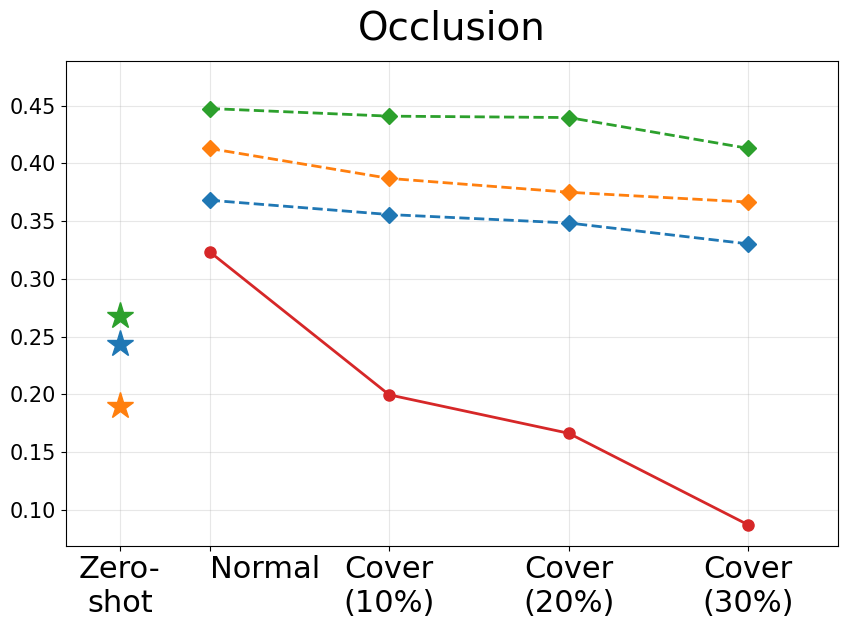

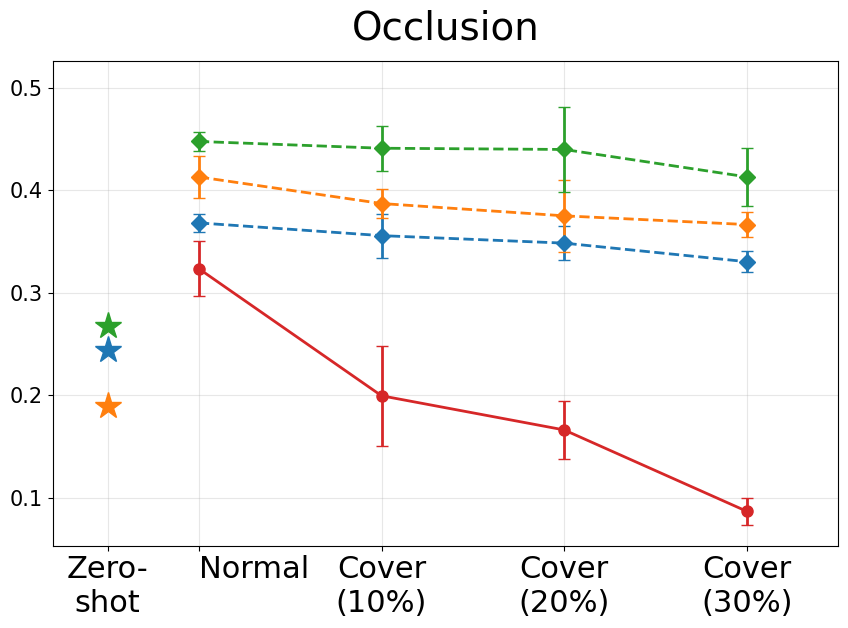

In [13]:
# SIMD, 4 end

cover_labels = ["Normal", "Cover\n(10%)", "Cover\n(20%)", "Cover\n(30%)"]

data_10shot = {
    "CLIP": {
        "zero-shot": 0.2438,
        #"ovdsat": [0.2304, 0.1241, 0.1105, 0.0912],
        "coop":   [0.3681, 0.3557, 0.3484, 0.3303],
    },
    "RemoteCLIP": {
        "zero-shot": 0.1898,
        #"ovdsat": [0.1979, 0.1149, 0.0929, 0.0904],
        "coop":   [0.4129, 0.3870, 0.3750, 0.3665],
    },
    "GeorsCLIP": {
        "zero-shot": 0.2679,
        #"ovdsat": [0.1890, 0.1328, 0.0984, 0.0953],
        "coop":   [0.4475, 0.4409, 0.4397, 0.4130],
    },
    "Dinov2": {
        "ovdsat": [0.3234, 0.1996, 0.1663, 0.0870],
    },
}

std_10shot = {
    "CLIP": {
        "coop": [0.0086, 0.0214, 0.0163, 0.0100],
    },
    "RemoteCLIP": {
        "coop": [0.0206, 0.0140, 0.0353, 0.0119],
    },
    "GeorsCLIP": {
        "coop": [0.0094, 0.0218, 0.0410, 0.0282],
    },
    "Dinov2": {
        "ovdsat": [0.0266, 0.0485, 0.0281, 0.0132],
    },
}

plot_degrade_results(
    data_10shot,
    "Occlusion",
    cover_labels,
    "Cover Percentage",
)

plot_degrade_results(
    data_10shot,
    "Occlusion",
    cover_labels,
    "Cover Percentage",
    std_10shot,
    error_style='bars'
)

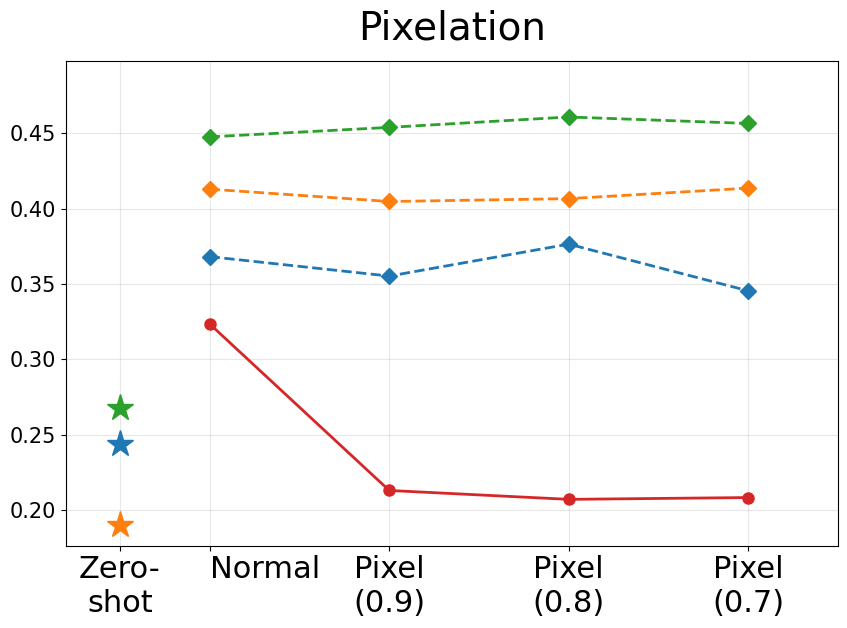

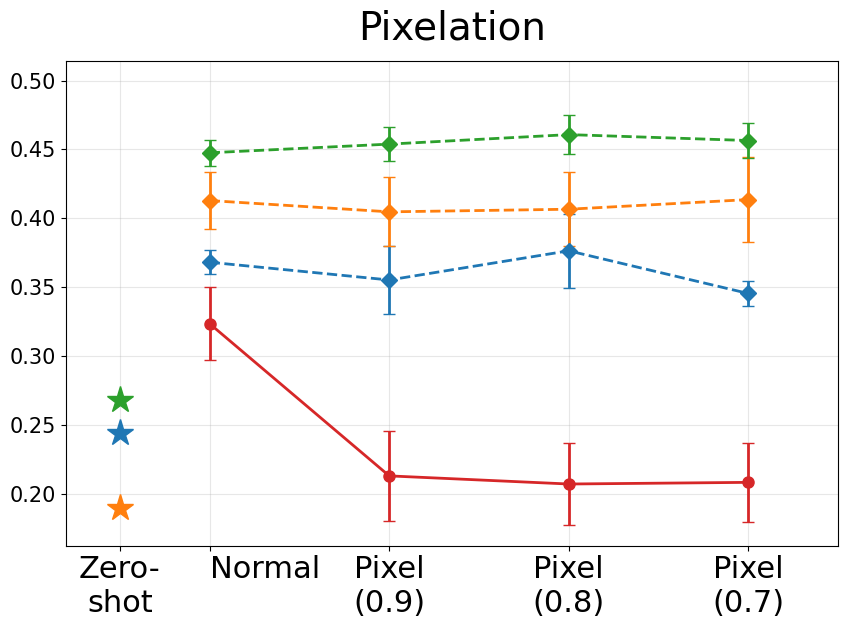

In [14]:
# SIMD, 4 end

# Pixel
pixel_labels = ["Normal", "Pixel\n(0.9)", "Pixel\n(0.8)", "Pixel\n(0.7)"]

data_10shot = {
    "CLIP": {
        "zero-shot": 0.2438,
        "coop": [0.3681, 0.3552, 0.3764, 0.3454],
    },
    "RemoteCLIP": {
        "zero-shot": 0.1898,
        "coop": [0.4129, 0.4047, 0.4066, 0.4136],
    },
    "GeorsCLIP": {
        "zero-shot": 0.2679,
        "coop": [0.4476, 0.4539, 0.4608, 0.4565],
    },
    "Dinov2": {
        "ovdsat": [0.3234, 0.2129, 0.2070, 0.2082],
    },
}

std_10shot = {
    "CLIP": {
        "coop": [0.0086, 0.0250, 0.0268, 0.0093],
    },
    "RemoteCLIP": {
        "coop": [0.0206, 0.0250, 0.0268, 0.0309],
    },
    "GeorsCLIP": {
        "coop": [0.0094, 0.0124, 0.0142, 0.0129],
    },
    "Dinov2": {
        "ovdsat": [0.0266, 0.0326, 0.0299, 0.0289],
    },
}

plot_degrade_results(
    data_10shot,
    "Pixelation",
    pixel_labels,
    "Scale",
)

plot_degrade_results(
    data_10shot,
    "Pixelation",
    pixel_labels,
    "Scale",
    std_10shot,
    error_style='bars'
)